# Lab 1: Introduction to EDA and ETL in Data Engineering
A data team typically contains several different roles:
- *data engineer*: maintain the infrastructure and workflows that allow data to move from raw sources into reliable, usable forms
- *data analysts*: build dashboards and business reports
- *data scientists*: explore patterns and develop predictive models
- *machine learning engineers*: deploy and maintain ML systems
- *product/ business teams*: make decisions based on data

In data engineering, raw data often arrives in messy or inconvenient formats. Before it can be used for analytics, machine learning, or reporting, we need to **inspect it, clean it, transform it, and store it** in a more usable form.

In this lab, you will be introduced to 2 key tasks in data engineering:
- **Exploratory Data Analysis (EDA)**: understanding the structure, quality, and patterns of a dataset
- **Extract, Transform, Load (ETL)**: building a simple pipeline to ingest, clean, and store data for downstream use

We will use a flight dataset as the main example and connect EDA with ETL as two parts of the same workflow.

## Exploratory Data Analysis (EDA)
EDA helps data engineers to understand
- what the data looks like
- whether the data is complete and trustworthy
- whether the schema is consistent
- whether downstream users can actually use it

A typical EDA process is involved with exploring
- size and shape
- column meanings and types
- missing values
- unusual values or outliers
- distributions
- relationships between variables

## Extract, Transform, Load (ETL)
ETL stands for:

- **Extract**: get data from one or more sources
- **Transform**: clean, standardize, enrich, and validate it
- **Load**: store it into a target system for later use

Typical workflow:
1. Extract raw data
2. Inspect structure and sample rows
3. Compute summary statistics
4. Visualize key variables
5. Identify data quality issues
6. Transform data
7. Save cleaned data for downstream use

## Exercise: Carrier On-Time Performance Dataset
### 1. Setup and data loading
Load the load with 29 columns out of 109:

[
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline", 
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

And check the shape of the loaded data

In [1]:
import pandas as pd
import numpy as np

## Read data using 29 columns
use_cols = [
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline", 
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

DATA_DIR = ''

## TO DO: read_csv()
df = pd.read_csv("airline_2019.csv")[use_cols]
## Check the shape of the loaded data
df.shape

/var/folders/9y/nhtlk1191r78kf_7vfn0gm880000gn/T/ipykernel_81285/3155546673.py:18: DtypeWarning: Columns (0: Div2Airport, 1: Div2TailNum) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("airline_2019.csv")[use_cols]


(76616, 29)

#### 1.1 Rename a few columns:
- "Reporting_Airline" -->  "UniqueCarrier"
- "Flight_Number_Reporting_Airline":"FlightNum"
- "Tail_Number":"TailNum"

A useful method here: `df.rename()` method: Original_Name:NewName
```python
df.rename(
    columns={
        
    },
    inplace=True
)
```

Column name convention:
 - **Snake Case Convention**: use underscores (_) to separate words
 - **Camel Case/ Pascal Case**: capitalize the first letter of each word

#### 1.2 Random sample 20k observations for further analysis 

In [2]:
## 1.1 Rename a few columns
df.rename(
    columns={
        "Reporting_Airline" : "UniqueCarrier",
        "Flight_Number_Reporting_Airline" : "FlightNum",
        "Tail_Number" : "TailNum"
    },
    inplace=True
)
## 1.2 Random sampling for further analysis
dfs = df.sample(20000).reset_index(drop=True)


### 2. Basic EDA

In [3]:
## Print first 5 rows to check how the data looks like
dfs.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2019,9,8,7,555.0,600,1048.0,1025,AS,88,...,27.0,10.0,0.0,NaN,0.0,0.0,0.0,23.0,0.0,0.0
1,2019,1,7,1,757.0,800,1148.0,1204,AA,156,...,3.0,19.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN
2,2019,1,28,1,606.0,615,836.0,851,YV,5813,...,8.0,11.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN
3,2019,8,29,4,1957.0,1954,2116.0,2114,DL,31,...,13.0,19.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN
4,2019,12,26,4,2314.0,839,256.0,1224,G4,2202,...,4.0,11.0,0.0,NaN,0.0,872.0,0.0,0.0,0.0,0.0


In [4]:
## Get descriptive statistics and missing value percentage for each column
def get_info(pd_frame):
    # generate descriptive statistics (like count, mean, std, min, etc.) for numeric columns
    res = pd_frame.describe().transpose()
    # calculate the missing percentage for each variable
    res['missing_percent'] = [(pd_frame.shape[0] - res.loc[ind, 'count'])/pd_frame.shape[0] for ind in res.index]
    # 
    res['unique_val'] = [len(pd_frame.loc[:,ind].value_counts()) for ind in res.index]
    res['var_type'] = ['Continuous' if res.loc[ind, 'unique_val'] >=100 else 'Categorical' for ind in res.index]
    return res
    
get_info(dfs)

,count,mean,std,min,25%,50%,75%,max,missing_percent,unique_val,var_type
Year,20000.0,2019.000000,0.000000,2019.0,2019.00,2019.0,2019.00,2019.0,0.00000,1,Categorical
Month,20000.0,6.564200,3.434278,1.0,4.00,7.0,10.00,12.0,0.00000,12,Categorical
DayofMonth,20000.0,15.586800,8.720377,1.0,8.00,16.0,23.00,31.0,0.00000,31,Categorical
DayOfWeek,20000.0,3.940200,2.004127,1.0,2.00,4.0,6.00,7.0,0.00000,7,Categorical
DepTime,19646.0,1335.364807,508.712726,1.0,916.25,1327.0,1747.00,2400.0,0.01770,1240,Continuous
CRSDepTime,20000.0,1332.178850,493.488868,5.0,917.00,1323.0,1740.00,2359.0,0.00000,1160,Continuous
ArrTime,19627.0,1470.211749,539.229141,1.0,1052.00,1506.0,1921.00,2400.0,0.01865,1323,Continuous
CRSArrTime,20000.0,1491.404550,518.139744,1.0,1105.00,1519.0,1923.25,2400.0,0.00000,1242,Continuous
FlightNum,20000.0,2552.377550,1808.630758,1.0,997.00,2147.5,3899.00,7436.0,0.00000,5716,Continuous
ActualElapsedTime,19591.0,136.583380,72.676414,27.0,83.00,119.0,168.00,665.0,0.02045,421,Continuous


### 3. Visualization and pattern finding
In this part, you need to:
#### 3.1 Visualize the value distribution of each column
#### 3.2 Calculate the missing value percentage of each column
#### 3.3 Visualize the #observations across DayofMonth & DayofWeek
#### 3.4 Visualize arrival and departure delays distribution
`sns.boxplot()` might be a useful function here to visualize spread, outliers, and quartiles.
```python
sns.boxplot(data=your_dataframe, x='categorical_column', y='numerical_column')
```

`sns.countplot()` will displays the count of observations for each category in a categorical variable.
```python
sns.countplot(data=your_dataframe, x='categorical_column')
```

In [5]:
disc_dfs = dfs.select_dtypes('int64')
disc_dfs.shape

(20000, 7)

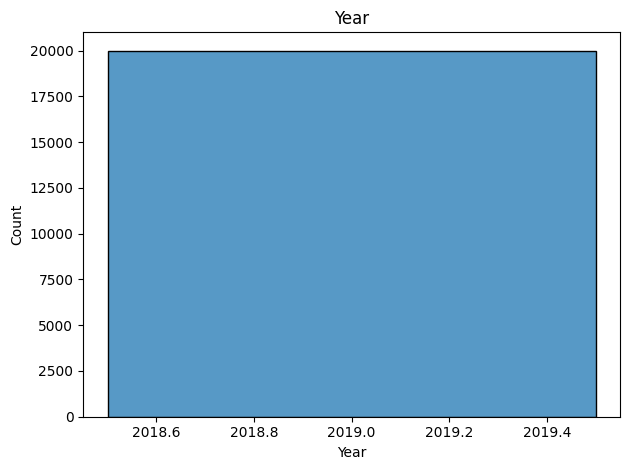

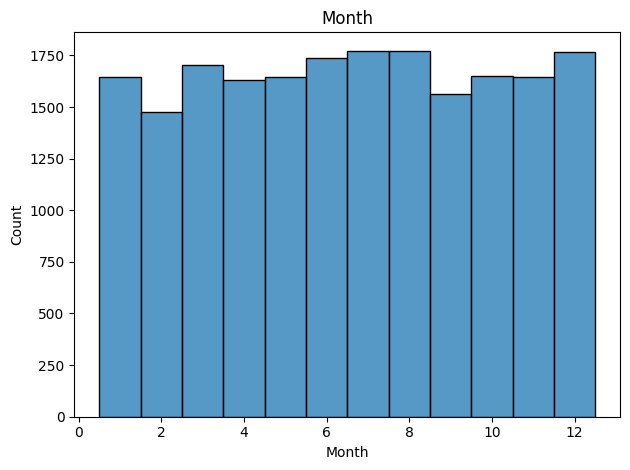

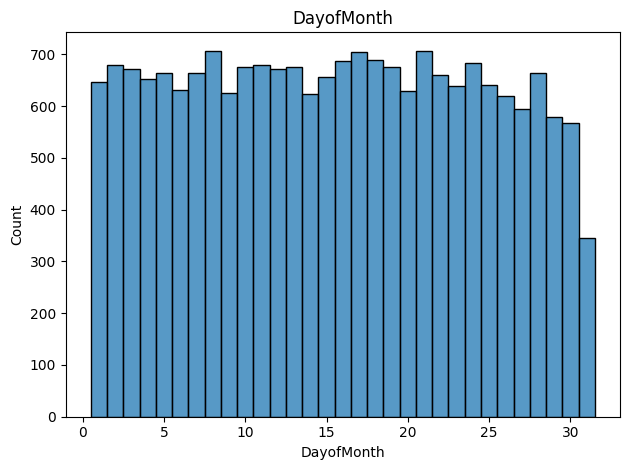

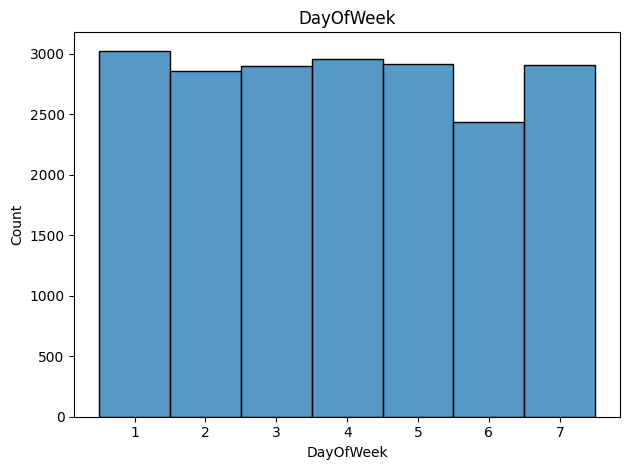

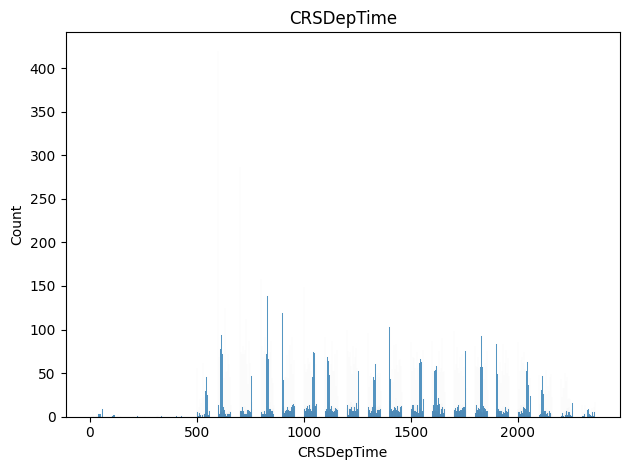

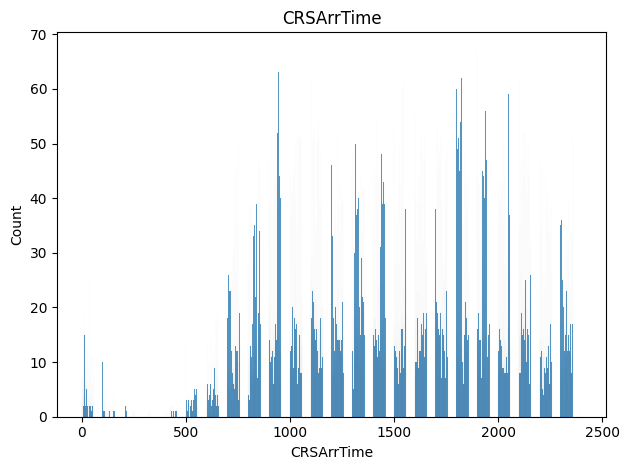

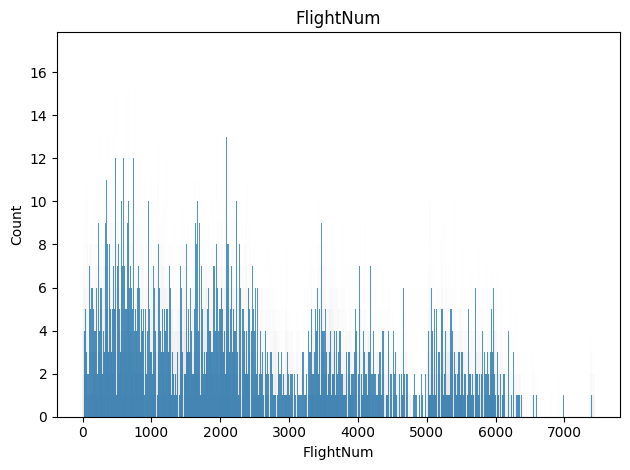

In [6]:
## 3.1 Visualize the value distribution of each column
## If the value type is continuous, we will use boxplot
## If the value type is discrete, we will use bar chart

import matplotlib.pyplot as plt
import seaborn as sns

for col in disc_dfs.columns:
    sns.histplot(data=disc_dfs, x=col, discrete=True)
    plt.title(str(col))
    plt.tight_layout()
    plt.show()


In [7]:
cont_dfs = dfs.select_dtypes('float64')
cont_dfs.shape

(20000, 17)

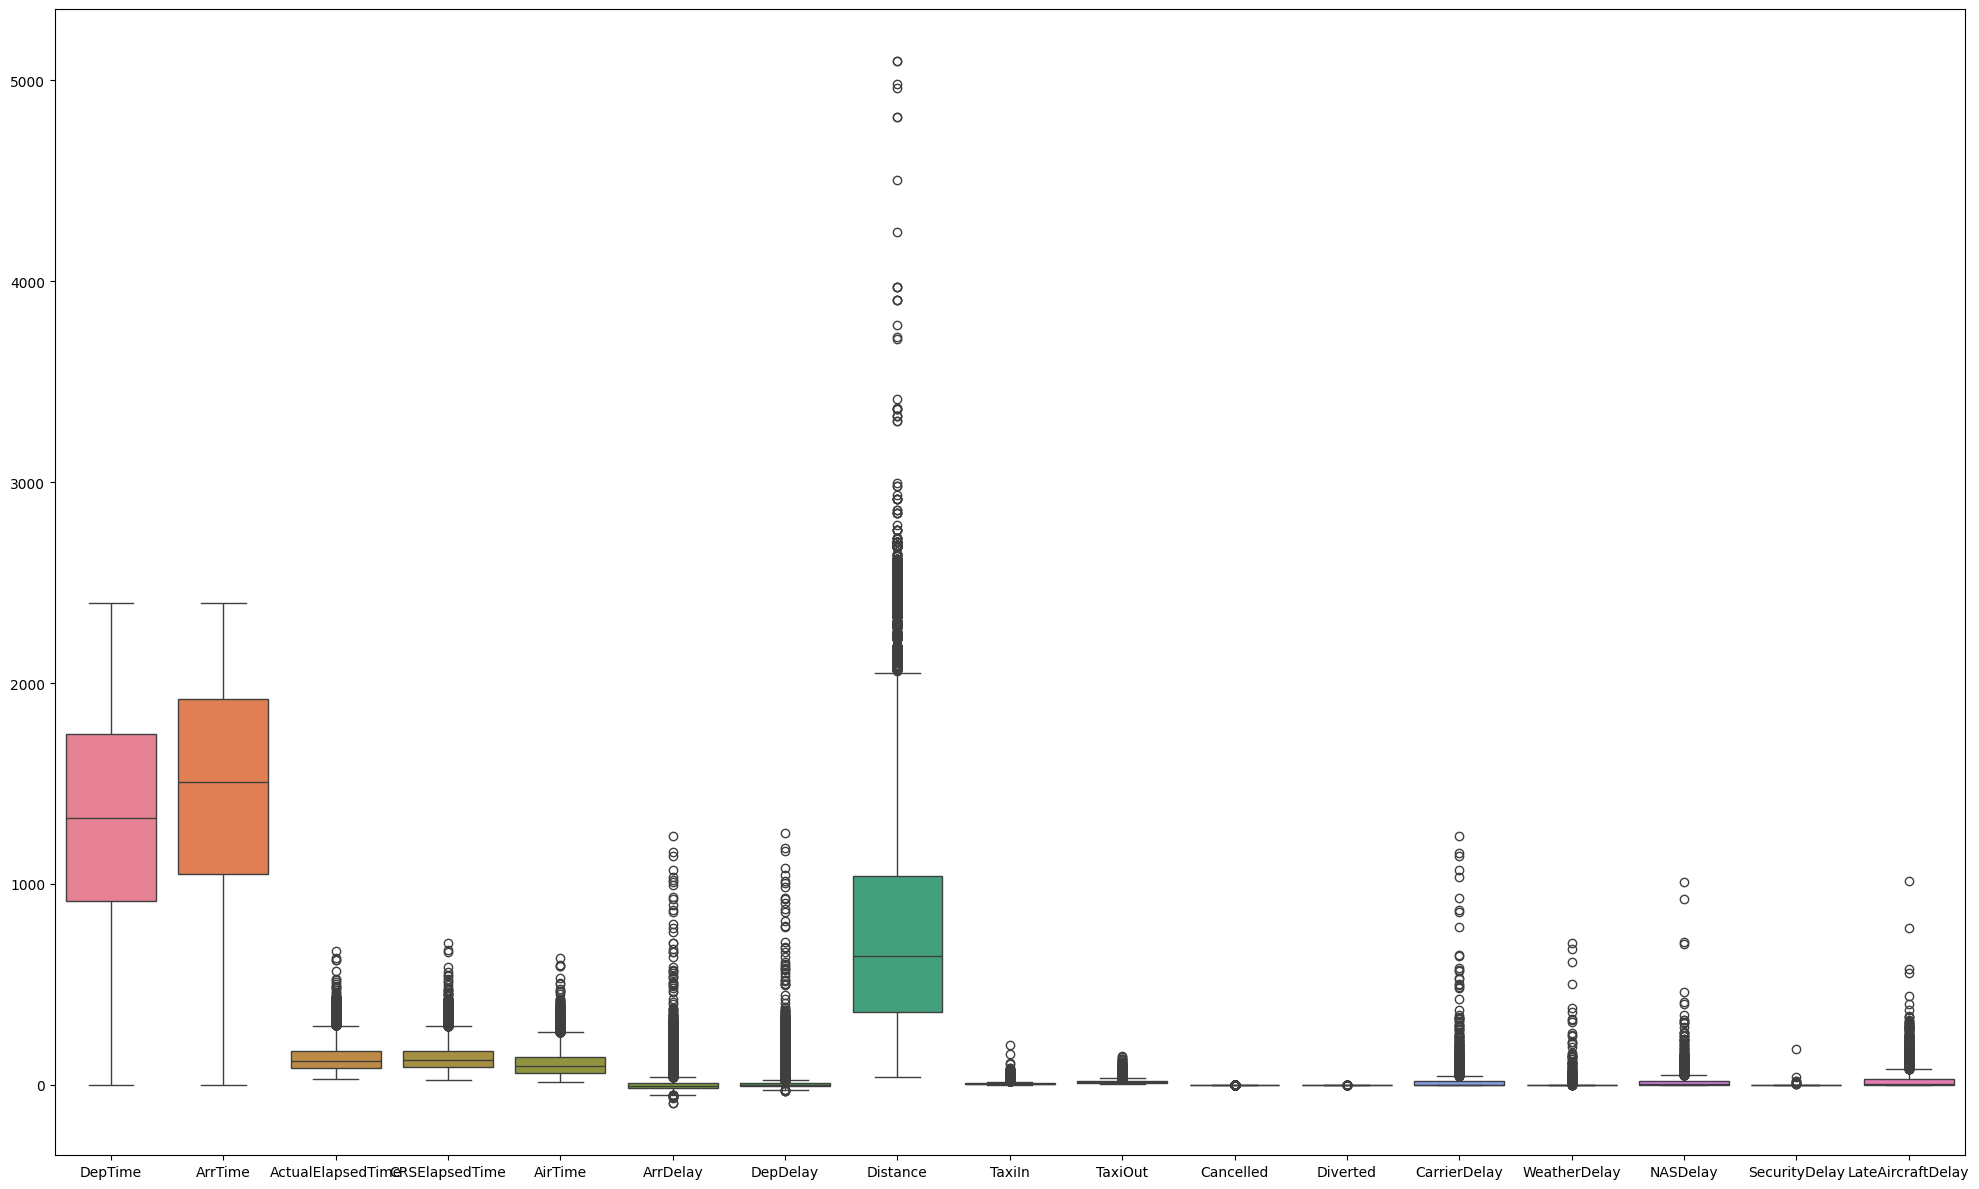

In [8]:
plt.figure(figsize=(20,12))
sns.boxplot(cont_dfs)    
plt.tight_layout()
plt.show()

In [9]:
## 3.2 Calculate the missing value percentage of each column
pd.Series(dfs.isna().sum() / len(dfs), name='missing_percent')

Year                 0.00000
Month                0.00000
DayofMonth           0.00000
DayOfWeek            0.00000
DepTime              0.01770
CRSDepTime           0.00000
ArrTime              0.01865
CRSArrTime           0.00000
UniqueCarrier        0.00000
FlightNum            0.00000
TailNum              0.00295
ActualElapsedTime    0.02045
CRSElapsedTime       0.00010
AirTime              0.02045
ArrDelay             0.02045
DepDelay             0.01770
Origin               0.00000
Dest                 0.00000
Distance             0.00000
TaxiIn               0.01865
TaxiOut              0.01820
Cancelled            0.00000
CancellationCode     0.98170
Diverted             0.00000
CarrierDelay         0.81175
WeatherDelay         0.81175
NASDelay             0.81175
SecurityDelay        0.81175
LateAircraftDelay    0.81175
Name: missing_percent, dtype: float64

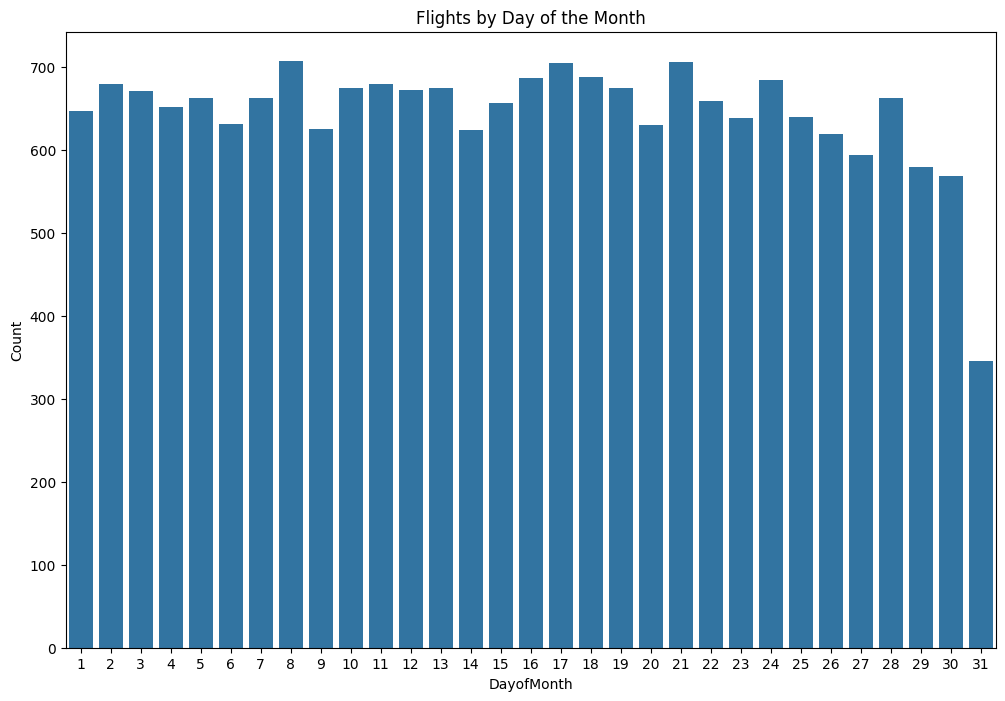

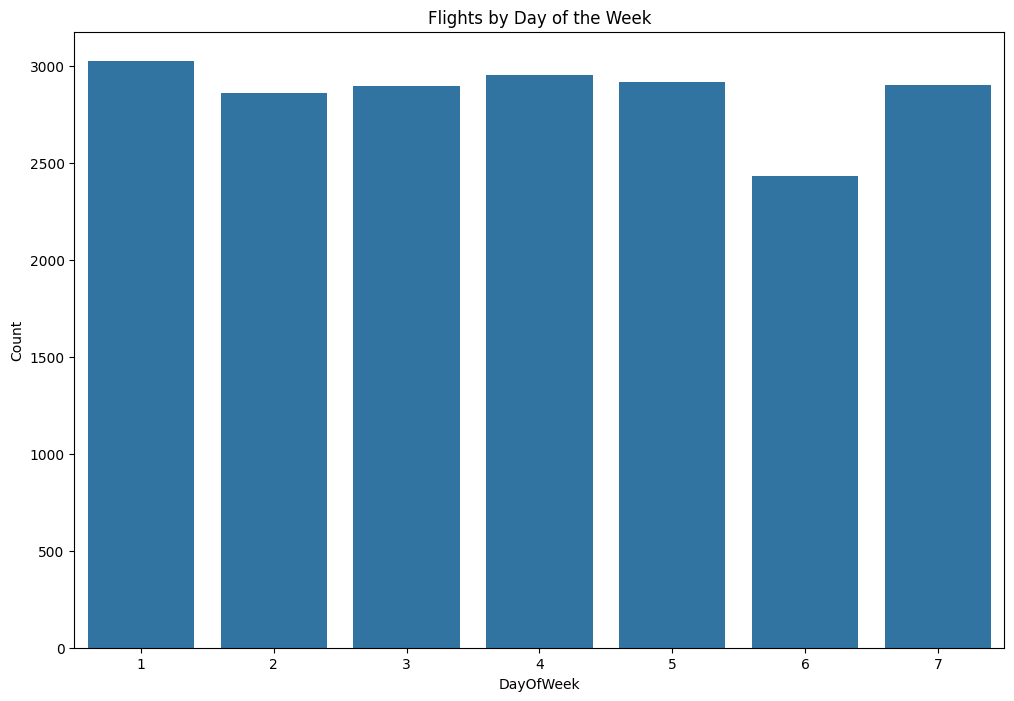

In [11]:
## 3.3 Count number of flights in different DayofMonth and DayOfWeek
day_of_month_counts = dfs.groupby('DayofMonth')['FlightNum'].count().reset_index(name='count')
plt.figure(figsize=(12,8))
sns.barplot(data=day_of_month_counts, x='DayofMonth', y='count')
plt.title('Flights by Day of the Month')
plt.ylabel('Count')
plt.show()


day_of_week_counts = dfs.groupby('DayOfWeek')['FlightNum'].count().reset_index(name='count')
plt.figure(figsize=(12,8))
sns.barplot(data=day_of_week_counts, x='DayOfWeek', y='count')
plt.title('Flights by Day of the Week')
plt.ylabel('Count')
plt.show()


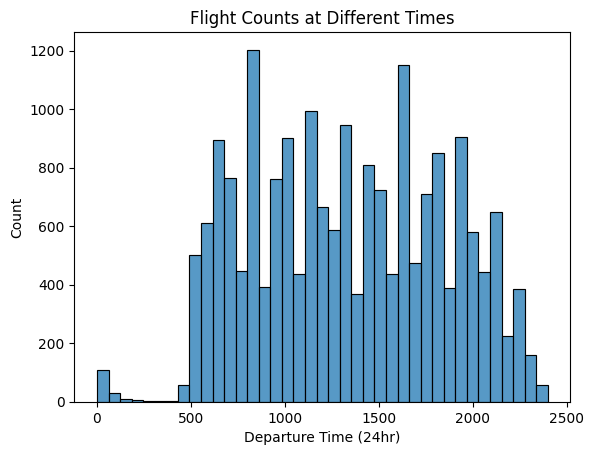

In [12]:
## 3.4.1 Histogram of Departure Time

dep_times = dfs['DepTime'].dropna()
sns.histplot(dep_times)
plt.title('Flight Counts at Different Times')
plt.xlabel('Departure Time (24hr)')
plt.show()

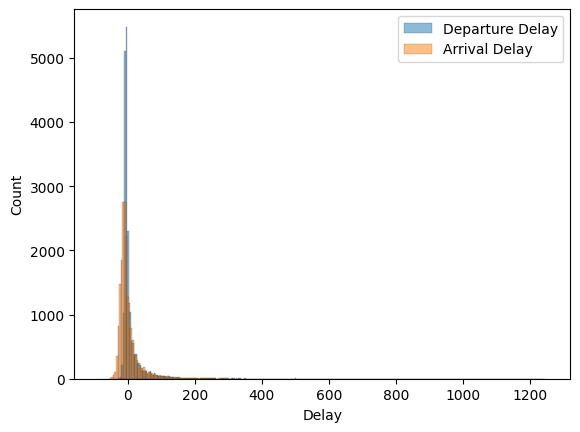

In [13]:
## 3.4.2 Histogram of arrival and departure delays
sns.histplot(dfs['DepDelay'].dropna(), label='Departure Delay', alpha=0.5)
sns.histplot(dfs['ArrDelay'].dropna(), label='Arrival Delay', alpha=0.5)
plt.xlabel('Delay')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Arrival Delay vs Departure Time')

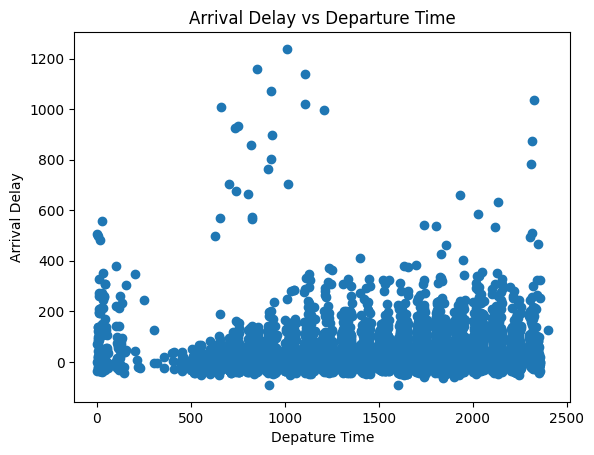

In [14]:
## 3.5.1 bivariate analysis: arrival delay vs departure time
# plot of arrival delay vs departure time Scatterplot
plt.scatter(y=dfs['ArrDelay'], x=dfs['DepTime'])
plt.ylabel('Arrival Delay')
plt.xlabel('Depature Time')
plt.title('Arrival Delay vs Departure Time')



Text(0.5, 1.0, 'Air time vs Distance')

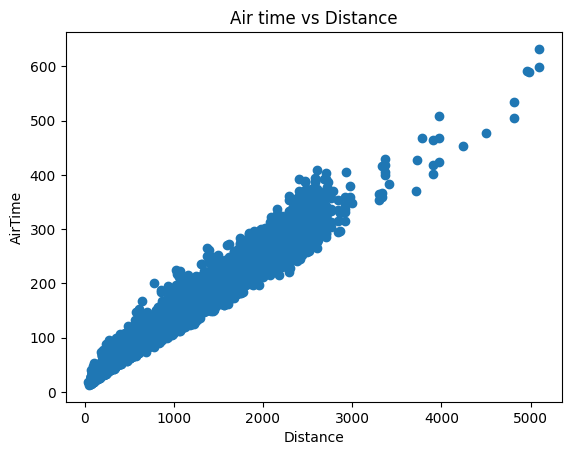

In [15]:
## 3.5.2 bivariate analysis: distance and airtimes
plt.scatter(x=dfs['Distance'], y=dfs['AirTime'])
plt.xlabel('Distance')
plt.ylabel('AirTime')
plt.title('Air time vs Distance')


### 4. Feature engineering and cleaning

In [16]:
## 4.1 creating a categorical column for weekday
mapping = {     
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
    }

dfs['WeekDay'] = dfs['DayOfWeek'].map(mapping)

In [17]:
## 4.2 first use a max(0,x) transform to get rid of negative values
## then create a new column using the log(1+x)
(dfs.select_dtypes('number') < 0).sum()

Year                     0
Month                    0
DayofMonth               0
DayOfWeek                0
DepTime                  0
CRSDepTime               0
ArrTime                  0
CRSArrTime               0
FlightNum                0
ActualElapsedTime        0
CRSElapsedTime           0
AirTime                  0
ArrDelay             12444
DepDelay             11875
Distance                 0
TaxiIn                   0
TaxiOut                  0
Cancelled                0
Diverted                 0
CarrierDelay             0
WeatherDelay             0
NASDelay                 0
SecurityDelay            0
LateAircraftDelay        0
dtype: int64

In [18]:
dfs['ArrDelay'] = dfs['ArrDelay'].clip(lower=0)
dfs['DepDelay'] = dfs['DepDelay'].clip(lower=0)

dfs['LogArrDelay'] = np.log(1 + dfs['ArrDelay'])
dfs['LogDepDelay'] = np.log(1 + dfs['DepDelay'])

In [19]:
## 4.3 Create a new column called 'DecimalDepTime', which convert 'CRSDepTime' (HHMM format) into decimal house
## For example: 1330 --> 13.5; 9:45 --> 9.75
dfs['DecimalDepTime'] = (dfs['CRSDepTime'] // 100) + (dfs['CRSDepTime'] % 100) / 60

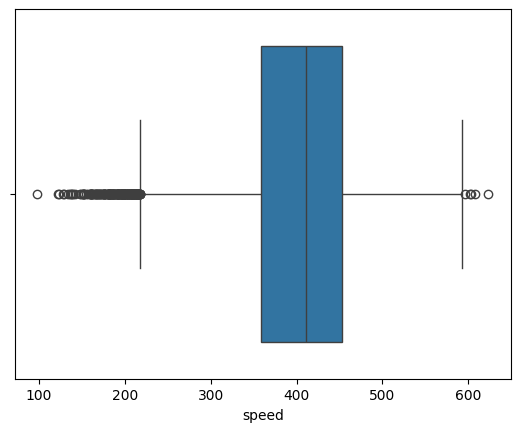

In [20]:
## 4.4 Create a new column 'speed', which is equal distance/AirTime. Make sure the unit of column is Miles Per Hour (mph)
dfs['speed'] = dfs['Distance'] / (dfs['AirTime'] / 60)
## boxplot of average speeds
sns.boxplot(x=dfs['speed'])
plt.show()

In [21]:
#### 4.5 Filter flights with speeds greater than 650 mph and calculate their proportion in the dataset.
dfs_fast = dfs.loc[dfs['speed'] > 650]
len(dfs_fast) / len(dfs)

0.0

### 5. Save transformed data
This corresponds to the "Load" part in ETL

Regarding the saved file format
- raw CSV is good for sharing
- Parquet is better for analytics workflows

You can choose whatever format you like to save the transformed data in this exercise.

In [23]:
## Save transformed data
dfs.to_csv('airline_2019_transformed.csv')